In [22]:
import os 
from typing import TypedDict,List,Dict,Any,Optional

from langgraph.graph import StateGraph,END,START
from langchain_google_genai import GoogleGenerativeAI
from langchain_core.messages import HumanMessage,AIMessage


In [11]:
api_key = ""

In [13]:
model = GoogleGenerativeAI(model="gemini-pro", google_api_key=api_key)

In [7]:
#define the state 
class EmailState(TypedDict):
    email : str 
    is_spam : Optional[bool] 
    spam_reason : Optional[str]
    email_category : Optional[str]
    draft_response : Optional[str]
    messages : List[Dict[str, Any]]

In [17]:
#define nodes 

def read_email(state: EmailState) :
    email = state["email"]
    print(f"Agent is processing the email from {email['sender']} with subject {email['subject']}")
    return {}

def classify_email(state : EmailState):
    email = state["email"]
    prompt = f""" 
     As Agent the email classifier, I will classify the email based on the subject and body.
     The email is from {email['sender']} with subject {email['subject']}.
        The body of the email is {email['body']}.
        The email is classified as spam or not spam.
        If it is spam, please provide the reason for the classification.
        If it is not spam, please provide the category of the email.
        The categories are:

    """
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)
    print(f"Agent is classifying the email with subject {email['subject']}")
    print(response.text)

    is_spam = "spam" in response.text.lower() and "not spam" not in response.text.lower()

    if not is_spam:
        new_messages = state.get("messages", []) + [
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": response.content}
        ]
    else:
        new_messages = state.get("message", []) 
    
    return {     "is_spam" : is_spam,
        "messages" : new_messages,
    }


def handle_spam(state : EmailState):
    print("The email is moved to the spam folde3r")
    return {}


def drafting_response(state : EmailState):
    email = state["email"]
    prompt = f""" 
    as agent drafter,draft a polite preliminary response to the email.
    The email is from {email['sender']} with subject {email['subject']}
    The body of the email is {email['body']}
    Draft a brie ,professional response that acknowledges the email and provides a preliminary response.
    """

    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)

    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]
    print(f"Agent is drafting a response to the email with subject {email['subject']}")
    print(response.text)

    return {
        "draft_response" : response.content,
        "messages" : new_messages,
    }


def notify_user(state : EmailState):
    email = state["email"]
    response = state["draft_response"]
    print(f"Agent is notifying the user about the email from {email['sender']} with subject {email['subject']}")
    print(f"Draft response: {response}")
    return {}




In [18]:
#define the routing logic 

def route_email(state : EmailState)->str:
    if state["is_spam"]:
        return "handle_spam"
    else :
        return "drafting_response"

In [19]:
#create a graph
email_graph = StateGraph(EmailState)

In [20]:
#add nodes 

email_graph.add_node("read_email", read_email)
email_graph.add_node("classify_email", classify_email)
email_graph.add_node("handle_spam", handle_spam)
email_graph.add_node("drafting_response", drafting_response)
email_graph.add_node("notify_user", notify_user)

In [23]:
#define routing logic 

email_graph.add_edge(START,"read_email")

email_graph.add_edge("read_email","classify_email")
email_graph.add_conditional_edges(
    "classify_email",
    route_email,
    {
        "handle_spam": "handle_spam",
        "drafting_response": "drafting_response"
    }
)



In [24]:
#add dinal grpah 

email_graph.add_edge("handle_spam",END)
email_graph.add_edge("drafting_response","notify_user")
email_graph.add_edge("notify_user",END)

In [25]:
#compile 

compiled_grpah = email_graph.compile()

In [26]:
from IPython.display import display, HTML,Image

In [ ]:
display(Image(compiled_grpah.get_graph().draw_mermaid_png()))

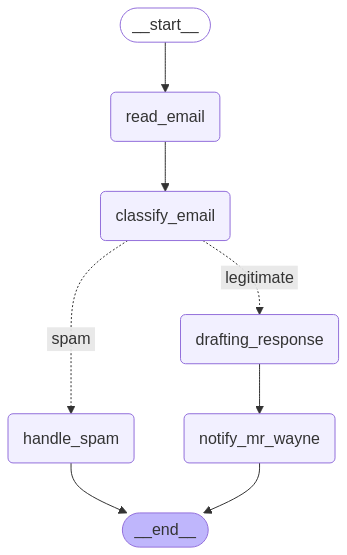

In [ ]:
legitimate_email = {
    "sender": "Joker",
    "subject": "Found you Batman ! ",
    "body": "Mr. Wayne,I found your secret identity ! I know you're batman ! Ther's no denying it, I have proof of that and I'm coming to find you soon. I'll get my revenge. JOKER"
}

spam_email = {
    "sender": "Crypto bro",
    "subject": "The best investment of 2025",
    "body": "Mr Wayne, I just launched an ALT coin and want you to buy some !"
}
# Process legitimate email
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke({
    "email": legitimate_email,
    "is_spam": None,
    "draft_response": None,
    "messages": []
})

# Process spam email
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke({
    "email": spam_email,
    "is_spam": None,
    "draft_response": None,
    "messages": []
}) 